# GMM-based Reduced Order Model + ML Mistuning Identification

This notebook is a simplified stand-in for the GMM (Generalized Model of
Mistuning) reduced order model from Krizak & D'Souza, *"A generalized model
of mistuning for bladed disks,"* J. Sound Vib. 606 (2025) 119003. The real
GMM ROM is built from finite element component mode synthesis (Craig-Bampton)
matrices that aren't available here, so instead this uses the classic
minimal 2-DOF-per-sector lumped model (one disk DOF + one blade DOF per
sector) that the paper itself points to as GMM's minimal ROM size (`2N` for
`N` sectors). Mistuning is added the same way GMM does it:

- a per-sector stiffness delta added to the blade's own diagonal stiffness
  term (paper Eqs. 15-16)
- a per-sector stiffness delta added to the disk's own diagonal term
  (Eqs. 17-19)
- a structural-damping delta matrix built the same way (Eq. 22)

The equation of motion solved is the complex-stiffness form of Eq. 21.

Swap `build_K`/`build_C` for matrices exported from a real GMM run and
everything below (dataset generation + ML identification) works unchanged.

Three identification cases are run at the end of this notebook:
1. stiffness mistuning only (damping tuned)
2. damping mistuning only (stiffness tuned)
3. both stiffness and damping mistuning together

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

np.random.seed(0)

## 1. Reduced order model: N sectors, 2 DOF each (disk DOF, blade DOF)

In [2]:
N = 24                 # number of blades / sectors
EO = 6                  # engine order of the forcing (traveling wave)
gamma_ave = 0.002       # tuned (baseline) structural damping coefficient

# lumped parameters (arbitrary but give a blade-dominated family ~300 Hz and a
# disk-influenced family ~500-800 Hz, similar in character to Fig. 2 of the paper)
m_b, m_d = 0.05, 1.0
k_bg = m_b * (2 * np.pi * 300) ** 2   # blade root ("cantilever") stiffness
k_bd = m_b * (2 * np.pi * 60) ** 2    # blade-to-disk coupling stiffness
k_dg = m_d * (2 * np.pi * 500) ** 2   # disk-to-hub stiffness
k_c = m_d * (2 * np.pi * 300) ** 2    # disk sector-to-sector (ring) coupling

# DOF ordering: [disk_1..disk_N, blade_1..blade_N]
M = np.zeros((2 * N, 2 * N))
for n in range(N):
    M[n, n] = m_d
    M[N + n, N + n] = m_b

In [3]:
def build_K(mB=None, mD=None):
    """Tuned + mistuned stiffness matrix.

    mB, mD : length-N arrays of fractional stiffness mistuning for the blades
    and disk sectors (m_n^B, m_n^D in the paper). None = tuned (all zero).
    """
    if mB is None:
        mB = np.zeros(N)
    if mD is None:
        mD = np.zeros(N)

    K = np.zeros((2 * N, 2 * N))
    for n in range(N):
        kbg_n = k_bg * (1 + mB[n])
        kdg_n = k_dg * (1 + mD[n])

        K[n, n] = kdg_n + k_bd + 2 * k_c          # disk sector n diagonal
        K[n, (n - 1) % N] += -k_c                  # ring coupling to neighbors
        K[n, (n + 1) % N] += -k_c

        K[N + n, N + n] = kbg_n + k_bd             # blade n diagonal
        K[n, N + n] = -k_bd                        # disk-blade coupling
        K[N + n, n] = -k_bd
    return K

In [4]:
def build_C(mB, gB, mD, gD):
    """Structural damping delta matrix (paper Eq. 22).

    gB, gD : length-N arrays of damping mistuning for the blades/disk
    (gamma_n^B, gamma_n^D in the paper).
    """
    C = np.zeros((2 * N, 2 * N))
    for n in range(N):
        C[N + n, N + n] = gB[n] * (1 + mB[n]) * k_bg
        C[n, n] = gD[n] * (1 + mD[n]) * k_dg
    return C

In [5]:
def forced_response(K, C, freqs):
    """Harmonic forced response (paper Eq. 21) for an engine-order traveling
    wave force applied on the blade DOFs. Returns blade-tip amplitude vs.
    frequency, shape (len(freqs), N)."""
    F = np.zeros(2 * N, dtype=complex)
    for n in range(N):
        F[N + n] = np.exp(1j * EO * 2 * np.pi * n / N)

    resp = np.zeros((len(freqs), N))
    for i, f in enumerate(freqs):
        w = 2 * np.pi * f
        A = -w ** 2 * M + (1 + 1j * gamma_ave) * K + 1j * C
        x = np.linalg.solve(A, F)
        resp[i, :] = np.abs(x[N:])
    return resp

### Sanity check: tuned forced response

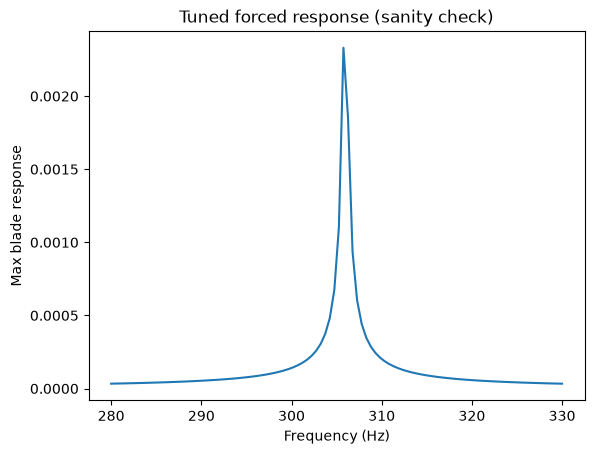

In [6]:
# frequency sweep around the tuned blade-dominated resonance (~306 Hz)
freqs = np.linspace(280, 330, 100)

K_tuned = build_K()
C_tuned = build_C(np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N))
resp_tuned = forced_response(K_tuned, C_tuned, freqs)

plt.figure()
plt.plot(freqs, resp_tuned.max(axis=1))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Max blade response")
plt.title("Tuned forced response (sanity check)")
plt.savefig("results_tuned_response.png", dpi=150)
plt.show()

## 2. Dataset generation: random mistuning patterns -> forced response curves

In [7]:
def make_dataset(n_samples, stiffness_on, damping_on,
                  sigma_k=0.02, damp_mean=0.002, damp_sigma=0.001):
    """Simulate n_samples random mistuning cases and record the blade forced
    response as the ML input feature (X) and the mistuning values as the
    label (Y)."""
    X, Y = [], []
    for _ in range(n_samples):
        mB = np.random.normal(0, sigma_k, N) if stiffness_on else np.zeros(N)
        gB = np.random.normal(damp_mean, damp_sigma, N) if damping_on else np.zeros(N)

        K = build_K(mB=mB)
        C = build_C(mB, gB, np.zeros(N), np.zeros(N))
        resp = forced_response(K, C, freqs)

        X.append(resp.flatten())
        if stiffness_on and damping_on:
            Y.append(np.concatenate([mB, gB]))
        elif stiffness_on:
            Y.append(mB)
        else:
            Y.append(gB)
    return np.array(X), np.array(Y)

## 3. Train / evaluate an ML model (neural network) for each mistuning case

In [8]:
def run_case(name, stiffness_on, damping_on, n_samples=1500):
    print(f"\n=== {name} ===")
    X, Y = make_dataset(n_samples, stiffness_on, damping_on)
    Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.2, random_state=0)

    # scale both inputs and outputs -- the mistuning targets are tiny
    # (fractions of a percent to a few percent) and an unscaled MLP trains
    # very poorly on targets that small.
    x_scaler = StandardScaler().fit(Xtr)
    y_scaler = StandardScaler().fit(Ytr)
    Xtr_s, Xte_s = x_scaler.transform(Xtr), x_scaler.transform(Xte)
    Ytr_s = y_scaler.transform(Ytr)

    model = MLPRegressor(hidden_layer_sizes=(64,), max_iter=2000, alpha=1e-2,
                          solver="adam", early_stopping=True, random_state=0)
    model.fit(Xtr_s, Ytr_s)

    pred = y_scaler.inverse_transform(model.predict(Xte_s))
    r2 = r2_score(Yte, pred)
    rmse = np.sqrt(np.mean((pred - Yte) ** 2))
    print(f"R2 = {r2:.4f}   RMSE = {rmse:.5f}")

    plt.figure(figsize=(5, 5))
    plt.scatter(Yte.flatten(), pred.flatten(), s=8, alpha=0.5)
    lims = [min(Yte.min(), pred.min()), max(Yte.max(), pred.max())]
    plt.plot(lims, lims, "r--")
    plt.xlabel("True mistuning")
    plt.ylabel("Predicted mistuning")
    plt.title(f"{name}  (R2={r2:.3f})")
    plt.tight_layout()
    plt.savefig(f"results_{name}.png", dpi=150)
    plt.show()

    return r2, rmse

### Case 1: stiffness mistuning only (damping tuned)


=== stiffness_only ===


R2 = 0.7342   RMSE = 0.01026


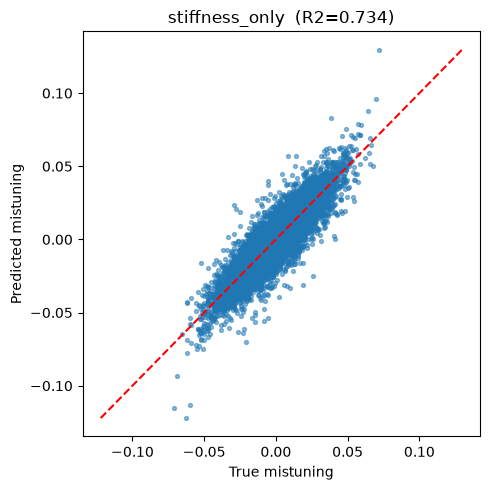

(0.734243132576947, np.float64(0.010256575263400857))

In [9]:
run_case("stiffness_only", stiffness_on=True, damping_on=False)

### Case 2: damping mistuning only (stiffness tuned)


=== damping_only ===


R2 = 0.9976   RMSE = 0.00005


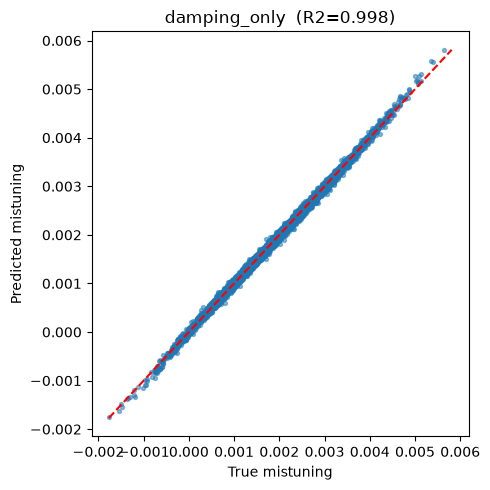

(0.9976026713219266, np.float64(4.880088064055055e-05))

In [10]:
run_case("damping_only", stiffness_on=False, damping_on=True)

### Case 3: stiffness and damping mistuning together


=== combined ===


R2 = 0.6563   RMSE = 0.00646


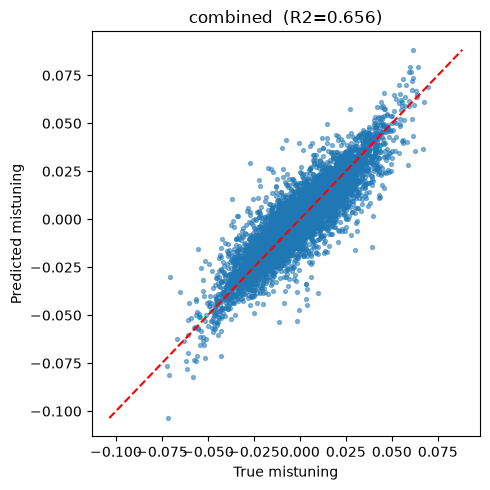

(0.6563090946448732, np.float64(0.006464869773025931))

In [11]:
run_case("combined", stiffness_on=True, damping_on=True)